In [ ]:
# import modules
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from libpysal.weights import KNN
from esda import Moran
import numpy as np

# load data

fastfood = gpd.read_file("Data/fastfood_location_name_amenity.gpkg")
crashes = pd.read_csv("Data/CrashStatisticsFranklinCounty.csv")

# drop missing coords
crashes = crashes.dropna(subset=["Latitude", "Longitude"])

# create GeoDataFrames
gdf_crashes = gpd.GeoDataFrame(
    crashes,
    geometry=gpd.points_from_xy(crashes["Longitude"], crashes["Latitude"]),
    crs="EPSG:4326"
)
gdf_fastfood = fastfood.copy()

# ensure CRS match
if gdf_fastfood.crs.to_epsg() != 4326:
    gdf_fastfood = gdf_fastfood.to_crs(epsg=4326)


# compute distance to nearest fastfood outlet
# for computational efficiency, project to meters

gdf_crashes_m = gdf_crashes.to_crs(epsg=3857)
gdf_fastfood_m = gdf_fastfood.to_crs(epsg=3857)

# compute nearest fastfood distance for each crash
nearest_dist = []
for crash_point in gdf_crashes_m.geometry:
    dist = gdf_fastfood_m.distance(crash_point).min()
    nearest_dist.append(dist)

gdf_crashes_m["dist_to_fastfood_m"] = nearest_dist


# build spatial weights (neighbors)

# use KNN = 8 nearest crashes as neighborhood
w = KNN.from_dataframe(gdf_crashes_m, k=8)
w.transform = 'R'

# Moran's I
# variable of interest: inverse distance (closer = higher value)
gdf_crashes_m["fastfood_proximity"] = 1 / (gdf_crashes_m["dist_to_fastfood_m"] + 1)

moran = Moran(gdf_crashes_m["fastfood_proximity"], w)


print("Moran's I statistic:", moran.I)
print("Expected I (under null):", moran.EI)
print("Z-score:", moran.z)
print("p-value:", moran.p_sim)

if moran.p_sim < 0.05:
    print("Significant spatial autocorrelation detected.")
else:
    print("No significant spatial autocorrelation detected.")


C:\Users\boie.2\AppData\Local\Temp\ipykernel_36640\940278652.py:11: DtypeWarning: Columns (23,31) have mixed types. Specify dtype option on import or set low_memory=False.
  crashes = pd.read_csv("Data/CrashStatisticsFranklinCounty.csv")
c:\Users\boie.2\.conda\envs\erdos_ds_environment\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 29 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Moran's I statistic: 0.4922646996895794
Expected I (under null): -8.70852564660803e-06
Z-score: [-0.02013265 -0.11814759 -0.11870933 ...  0.07910131 -0.06720588
 -0.11196529]
p-value: 0.001
Significant spatial autocorrelation detected.


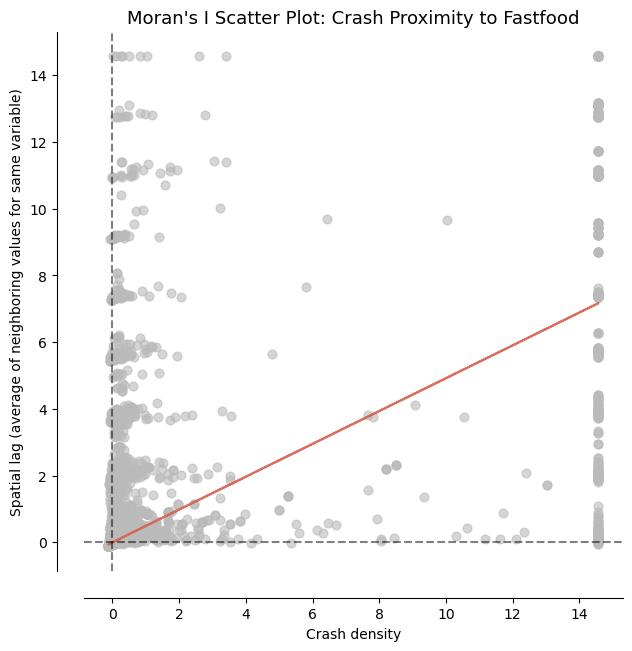

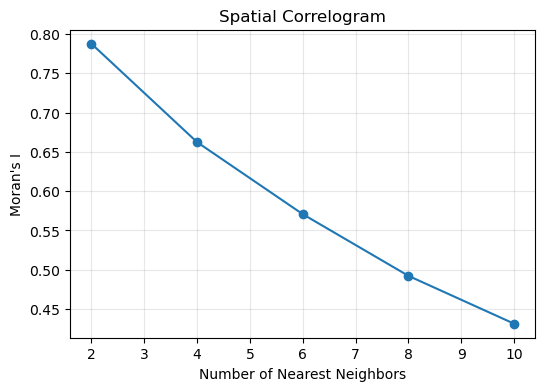

In [5]:
# Moran scatter plot (corrected)
import matplotlib.pyplot as plt
from esda.moran import Moran
from splot.esda import moran_scatterplot

fig, ax = moran_scatterplot(moran, aspect_equal=True)
ax.set_title("Moran's I Scatter Plot: Crash Proximity to Fastfood", fontsize=13)
ax.set_xlabel("Crash density")
ax.set_ylabel("Spatial lag (average of neighboring values for same variable)")
plt.show()

# Moran correlogram (spatial autocorrelation vs distance)
distances = [2, 4, 6, 8, 10]
morans = []
for k in distances:
    w_k = KNN.from_dataframe(gdf_crashes_m, k=k)
    w_k.transform = 'R'
    moran_k = Moran(gdf_crashes_m["fastfood_proximity"], w_k)
    morans.append(moran_k.I)

plt.figure(figsize=(6,4))
plt.plot(distances, morans, marker='o')
plt.title("Spatial Correlogram")
plt.xlabel("Number of Nearest Neighbors")
plt.ylabel("Moran's I")
plt.grid(True, alpha=0.3)
plt.show()


In [22]:
# load modules
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from mgwr.utils import shift_colormap


# Load crash and fastfood data
crashes = pd.read_csv("Data/CrashStatisticsFranklinCounty.csv").dropna(subset=["Latitude", "Longitude"])
fastfood = gpd.read_file("Data/fastfood_location_name_amenity.gpkg")

# Create GeoDataFrames
gdf_crashes = gpd.GeoDataFrame(
    crashes, geometry=gpd.points_from_xy(crashes["Longitude"], crashes["Latitude"]), crs="EPSG:4326"
)
gdf_fastfood = fastfood.to_crs(epsg=4326)

# Project to a local metric coordinate system (meters)
gdf_crashes_m = gdf_crashes.to_crs(epsg=3857)
gdf_fastfood_m = gdf_fastfood.to_crs(epsg=3857)

# create hexagonal grid to aggregate crashes
xmin, ymin, xmax, ymax = gdf_crashes_m.total_bounds
cell_size = 500  # 500 m grid

cols = np.arange(xmin, xmax + cell_size, cell_size)
rows = np.arange(ymin, ymax + cell_size, cell_size)

polygons = []
for x in cols:
    for y in rows:
        polygons.append(Point(x, y).buffer(cell_size / 2))

grid = gpd.GeoDataFrame(geometry=polygons, crs=gdf_crashes_m.crs)

# Count crashes in each grid cell
grid["crash_count"] = grid.geometry.apply(
    lambda g: gdf_crashes_m.within(g).sum()
)

# Count fastfood locations in each grid cell
grid["fastfood_count"] = grid.geometry.apply(
    lambda g: gdf_fastfood_m.within(g).sum()
)

# Filter cells with data (filter out low or zero counts)
grid = grid[(grid["crash_count"] > 0) & (grid["fastfood_count"] > 0)].copy()


# variables for GWR
# Dependent variable (crash density)
y = grid["crash_count"].values.reshape((-1, 1))

# Independent variable
X = grid[["fastfood_count"]].values  # can add more columns if available

# Coordinates
u = grid.geometry.centroid.x.values
v = grid.geometry.centroid.y.values
coords = np.column_stack((u, v))


# Select bandwidth and fit model
bw = Sel_BW(coords, y, X).search(bw_min=3)
print("Optimal bandwidth:", bw)

# Fit the GWR model
gwr_model = GWR(coords, y, X, bw)
gwr_results = gwr_model.fit()

print(gwr_results.summary())


# add results to GeoDataFrame

grid["beta_fastfood"] = gwr_results.params[:, 1]
grid["beta_intercept"] = gwr_results.params[:, 0]
grid["local_r2"] = gwr_results.localR2



C:\Users\boie.2\AppData\Local\Temp\ipykernel_36640\3922133057.py:8: DtypeWarning:

Columns (23,31) have mixed types. Specify dtype option on import or set low_memory=False.



Optimal bandwidth: 51.0
Model type                                                         Gaussian
Number of observations:                                                 292
Number of covariates:                                                     2

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                         744856.084
Log-likelihood:                                                   -1559.582
AIC:                                                               3123.164
AICc:                                                              3125.248
BIC:                                                             743209.825
R2:                                                                   0.079
Adj. R2:                                                              0.076

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ----

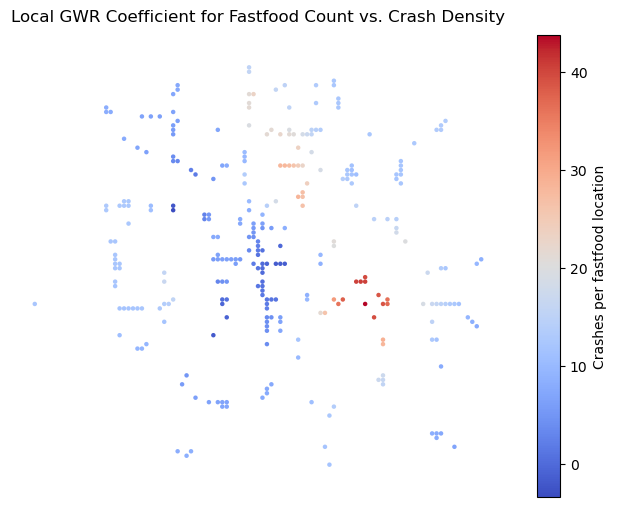

In [23]:
# plot local coefficients

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plot = grid.plot(column="beta_fastfood", cmap="coolwarm", legend=True, ax=ax)
cbar = plot.get_figure().axes[-1]

cbar.set_ylabel("Crashes per fastfood location")
ax.set_title("Local GWR Coefficient for Fastfood Count vs. Crash Density")
ax.axis("off")
plt.show()

In [24]:
print(grid_wgs84.crs)

EPSG:4326


In [26]:
# add the map in the plot
import plotly.express as px

# convert grid to WGS84

grid_wgs84 = grid.to_crs(epsg=4326)

# get coordinates
grid_wgs84["lon"] = grid_wgs84.geometry.centroid.x
grid_wgs84["lat"] = grid_wgs84.geometry.centroid.y

# new plot
fig = px.scatter_mapbox(
    grid_wgs84,
    lat="lat",
    lon="lon",
    color="beta_fastfood",
    color_continuous_scale=list(reversed(px.colors.diverging.RdBu)),
    size_max=15,
    zoom=10,
    mapbox_style="carto-positron",
    title="Local GWR Coefficient: Fastfood Count vs. Crash Density",
    labels={"beta_fastfood": "Crashes per fast food location"}
)

fig.show()



C:\Users\boie.2\AppData\Local\Temp\ipykernel_36640\3663772334.py:9: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


C:\Users\boie.2\AppData\Local\Temp\ipykernel_36640\3663772334.py:10: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


